Versuch 41

Auftragen der Druckwerte gegen Temperatur

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [89]:
T = np.array([0, 100])
p_0 = 906
p_0_error = 2.1
p_100 = 1250
p_100_error = 4

p_stickstoff = 250
p_stickstoff_error = 2.1

In [81]:
func = lambda T, m, c: m * T + c

popt, pcov = curve_fit(func, T, [p_0, p_100], sigma=[p_0_error, p_100_error])

m, c = popt
print(f"fitted func: p(T) = {m} * T + {c}")
print(f"covariance matrix: {pcov}")

fitted func: p(T) = 3.4399999999999995 * T + 906.0
covariance matrix: [[inf inf]
 [inf inf]]


c:\Users\coolc\anaconda3\Lib\site-packages\scipy\optimize\_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


T = (0 - c)/m (bei 0mbar)

In [82]:
temp = (0-c)/m
print(f"temperatur (0mbar) = {temp} C")

temperatur (0mbar) = -263.37209302325584 C


T stickstoff = (p_stickstoff - c)/m

In [86]:
temp_n2 = (p_stickstoff-c)/m
print(f"temperatur (Stickstoff) = {temp_n2} C")

temperatur (Stickstoff) = -190.6976744186047 C


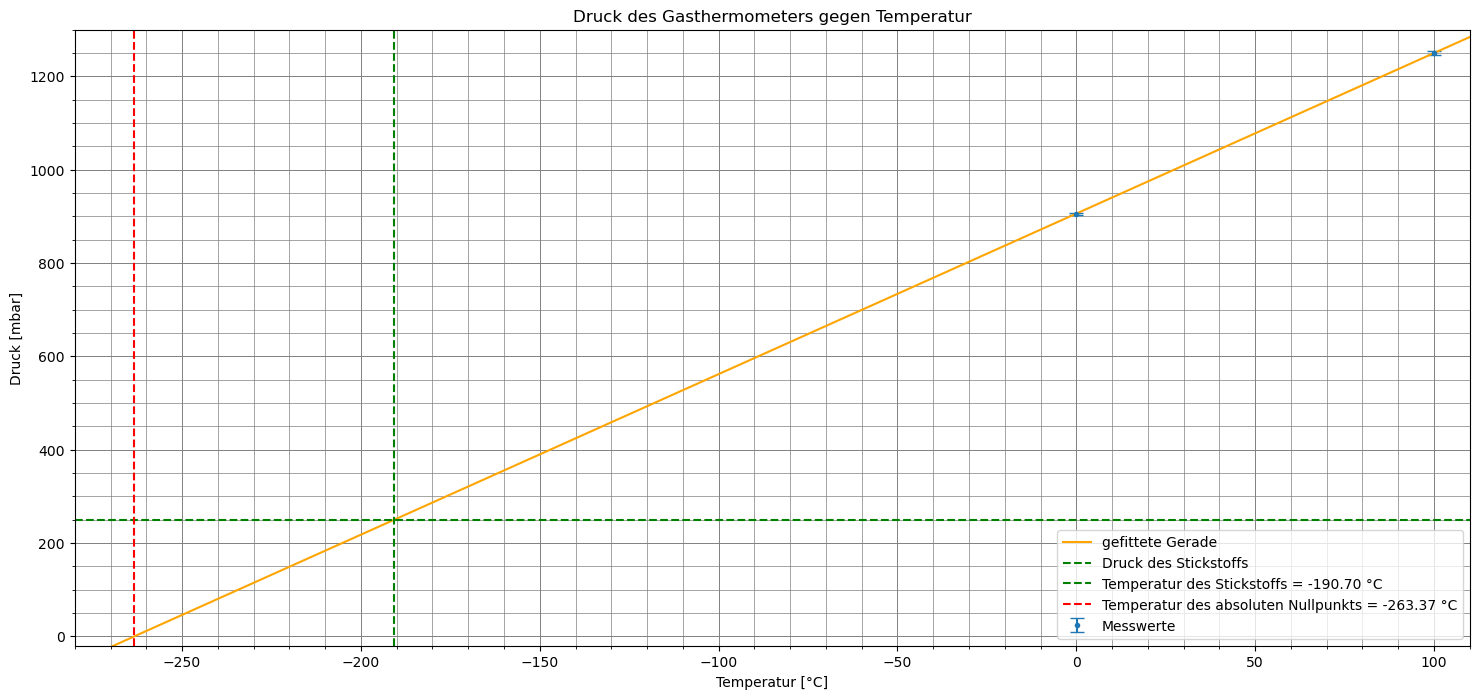

In [93]:
fig, ax = plt.subplots(figsize=(18, 8))

ax.errorbar(
    T, 
    [p_0, p_100],
    yerr=[p_0_error, p_100_error],
    fmt='.',
    capsize=5,
    label='Messwerte'
)

ax.plot(
    np.linspace(-280, 110, 100),
    func(np.linspace(-280, 110, 100), *popt),
    label='gefittete Gerade',
    color='orange'
)

ax.axhline(p_stickstoff,
           color='green',
           linestyle='--',
           label='Druck des Stickstoffs'
)

ax.axvline(temp_n2,
           color='green',
           linestyle='--',
           label=(f'Temperatur des Stickstoffs = {temp_n2:.2f} °C')
)

ax.axvline(temp,
           color='red',
           linestyle='--',
           label=(f'Temperatur des absoluten Nullpunkts = {temp:.2f} °C')
)


ax.set_title('Druck des Gasthermometers gegen Temperatur')
ax.set_xlabel('Temperatur [°C]')
ax.set_ylabel('Druck [mbar]')

ax.set_xlim(-280, 110)
ax.set_ylim(-20, 1300)

ax.minorticks_on()
ax.grid(which='major', linewidth=0.7, color='gray')
ax.grid(which='minor', linewidth=0.5, color='gray')

ax.legend()



<ErrorbarContainer object of 3 artists>

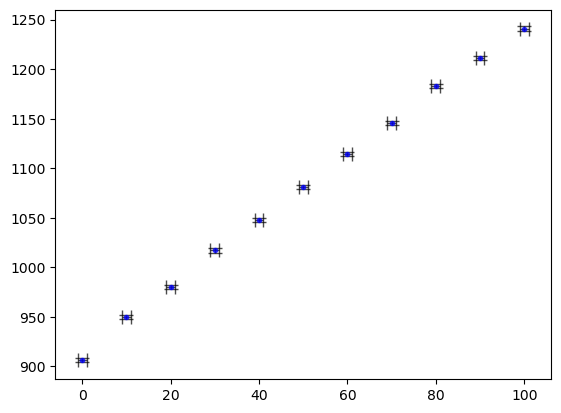

In [85]:
T = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
T_error = 1 #(fl)
pressure = np.array([906, 950, 980.4, 1017.0, 1048.0, 1081.0, 1114.0, 1146.0, 1182.8, 1211.0, 1241.0])
p_error = 2.1

plt.errorbar(T, pressure, xerr=T_error, yerr=p_error, fmt='.', ecolor='black', capsize=5, elinewidth=1, alpha=0.7, color='blue', label='Messwerte')
